# Lasso Regression from Scratch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## 1. Mock Data Generation

In [2]:
def generate_data(n_samples=100):
    X = np.random.rand(n_samples, 5)

    true_weights = np.array([4.0, 0.0, -2.5, 0.0, 1.2])
    true_bias = 2.0
    
    y = X @ true_weights + true_bias + np.random.normal(0, 0.1, n_samples)
    
    columns = [f"Feature_{i+1}" for i in range(5)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,0.374540,0.950714,0.731994,0.598658,0.156019,1.889574
1,0.155995,0.058084,0.866176,0.601115,0.708073,1.495842
2,0.020584,0.969910,0.832443,0.212339,0.181825,0.314464
3,0.183405,0.304242,0.524756,0.431945,0.291229,1.713512
4,0.611853,0.139494,0.292145,0.366362,0.456070,4.174492


## 2. Implementation

L1 Penalty: $Cost = MSE + \lambda \sum |w|$


In [ ]:
class LassoRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000, l1_penalty=1.0):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.lambda = l1_penalty
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            
            # Gradients with L1 regularization (Subgradient method)
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y)) + (self.lambda * np.sign(self.weights))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            cost = (1/(2*n_samples)) * np.sum((y_pred - y)**2) + self.lambda * np.sum(np.abs(self.weights))
            self.cost_history.append(cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

## 3. Training the Model

In [4]:
model = LassoRegressionGD(learning_rate=0.1, n_iterations=2000, l1_penalty=0.05)
model.fit(X, y)

print(f"Final Weights: {model.weights}")
print(f"Final Bias: {model.bias}")

Final Weights: [ 3.47617688e+00 -2.75242665e-05 -2.01265965e+00  6.99238301e-03
  6.32037724e-01]
Final Bias: 2.28335677233889


## 4. Visualization of Results

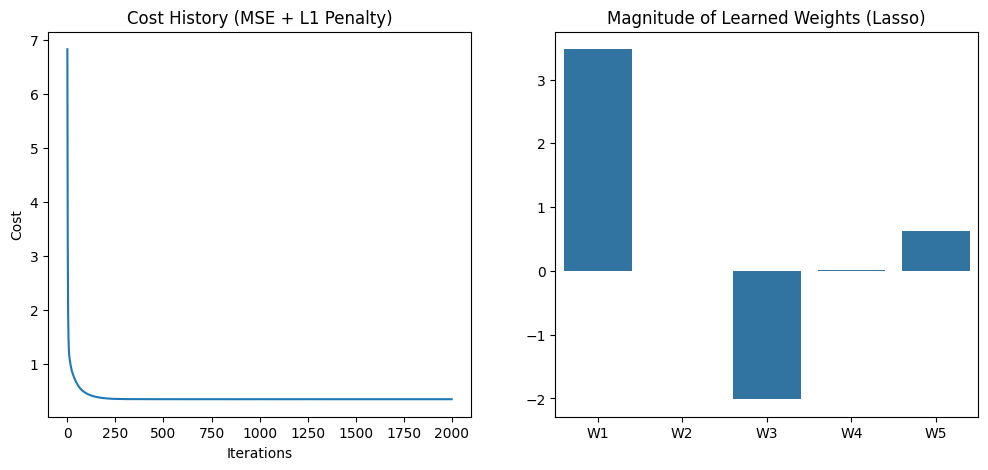

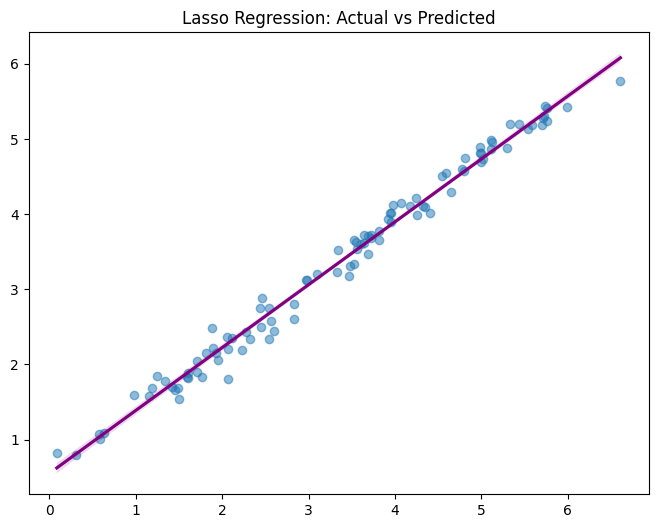

In [5]:
y_pred = model.predict(X)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model.cost_history)
plt.title("Cost History (MSE + L1 Penalty)")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.subplot(1, 2, 2)
sns.barplot(x=[f"W{i+1}" for i in range(5)], y=model.weights)
plt.title("Magnitude of Learned Weights (Lasso)")
plt.show()

plt.figure(figsize=(8, 6))
sns.regplot(x=y, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'purple'})
plt.title("Lasso Regression: Actual vs Predicted")
plt.show()